In [1]:
import pandas as pd

# 1. Load Datasets
flights_df = pd.read_csv('flights.csv')
hotels_df = pd.read_csv('hotels.csv')
users_df = pd.read_csv('users.csv')

# 2. Standardize User Key
users_df.rename(columns={'code': 'userCode', 'name': 'userName'}, inplace=True)
hotels_df.rename(columns={'name': 'hotelName', 'price': 'hotelDailyPrice', 'date': 'hotelDate'}, inplace=True)
flights_df.rename(columns={'price': 'flightPrice', 'date': 'flightDate'}, inplace=True)

# 3. Convert Date Columns to Datetime
flights_df['flightDate'] = pd.to_datetime(flights_df['flightDate'])
hotels_df['hotelDate'] = pd.to_datetime(hotels_df['hotelDate'])

# 4. Merge Data
# Merge flights with user profiles
flights_users_df = pd.merge(flights_df, users_df, on='userCode', how='left')

# Merge travel records (flights + hotels on travelCode & userCode)
master_df = pd.merge(
    flights_users_df, 
    hotels_df[['travelCode', 'userCode', 'hotelName', 'place', 'days', 'hotelDailyPrice', 'total', 'hotelDate']], 
    on=['travelCode', 'userCode'], 
    how='left'
)

print("Master DataFrame Shape:", master_df.shape)
print("\nMaster DataFrame Sample:")
print(master_df.head())

Master DataFrame Shape: (271888, 20)

Master DataFrame Sample:
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

   flightPrice  time  distance       agency flightDate company   userName  \
0      1434.38  1.76    676.53  FlyingDrops 2019-09-26    4You  Roy Braun   
1      1292.29  1.76    676.53  FlyingDrops 2019-09-30    4You  Roy Braun   
2      1487.52  1.66    637.56      CloudFy 2019-10-03    4You  Roy Braun   
3      1127.36  1.66    637.56      CloudFy 2019-10-04    4You  Roy Braun   
4      1684.05  2.16    830.86      CloudFy 2019-10-10    4You  Roy Braun   


Total Flight Spend: $260,298,782.14
Total Hotel Spend:  $21,745,179.21
Avg Flight Cost:    $957.38
Avg Hotel Spend:    $536.23


C:\Users\kartik\AppData\Local\Temp\ipykernel_5712\1404963749.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=flights_df, x='flightType', palette='viridis')


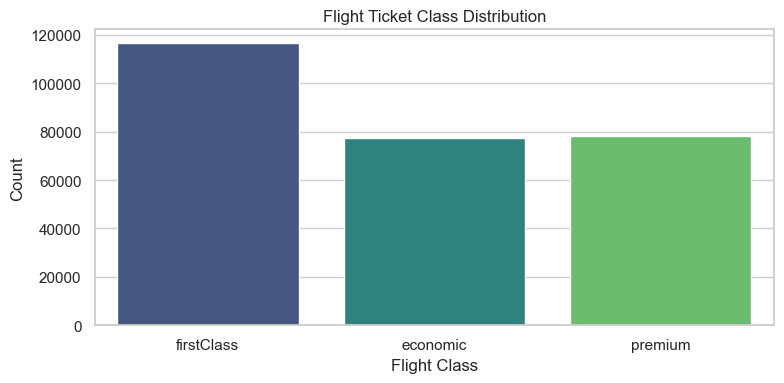

C:\Users\kartik\AppData\Local\Temp\ipykernel_5712\1404963749.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agency_revenue, x='agency', y='flightPrice', palette='mako')


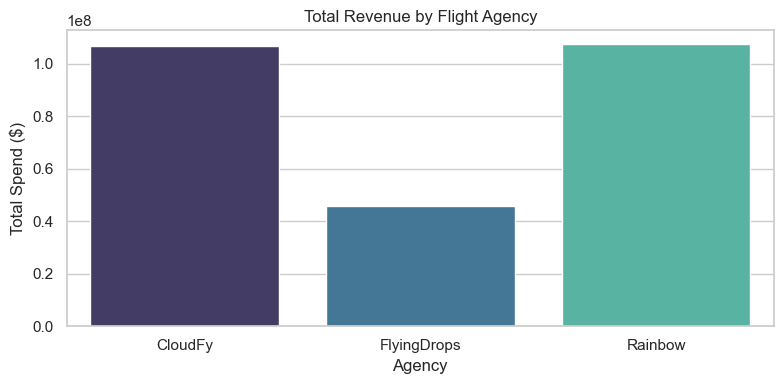

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Overall Metrics Overview
total_revenue_flights = flights_df['flightPrice'].sum()
total_revenue_hotels = hotels_df['total'].sum()
avg_flight_cost = flights_df['flightPrice'].mean()
avg_hotel_cost = hotels_df['total'].mean()

print(f"Total Flight Spend: ${total_revenue_flights:,.2f}")
print(f"Total Hotel Spend:  ${total_revenue_hotels:,.2f}")
print(f"Avg Flight Cost:    ${avg_flight_cost:,.2f}")
print(f"Avg Hotel Spend:    ${avg_hotel_cost:,.2f}")

# 2. Distribution of Flight Types
plt.figure(figsize=(8, 4))
sns.countplot(data=flights_df, x='flightType', palette='viridis')
plt.title('Flight Ticket Class Distribution')
plt.xlabel('Flight Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Top Flight Agencies by Revenue
agency_revenue = flights_df.groupby('agency')['flightPrice'].sum().reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=agency_revenue, x='agency', y='flightPrice', palette='mako')
plt.title('Total Revenue by Flight Agency')
plt.xlabel('Agency')
plt.ylabel('Total Spend ($)')
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# Load datasets
flights_df = pd.read_csv('flights.csv')
hotels_df = pd.read_csv('hotels.csv')
users_df = pd.read_csv('users.csv')

# Standardize user ID key
users_df.rename(columns={'code': 'userCode', 'name': 'userName'}, inplace=True)

# 1. Temporal Feature Extraction
flights_df['date'] = pd.to_datetime(flights_df['date'])
flights_df['month'] = flights_df['date'].dt.month
flights_df['dayofweek'] = flights_df['date'].dt.dayofweek
flights_df['is_weekend'] = flights_df['dayofweek'].isin([5, 6]).astype(int)

# 2. Route Identifier
flights_df['route'] = flights_df['from'] + ' -> ' + flights_df['to']

# 3. Merge Flights with User Demographics
df = pd.merge(flights_df, users_df, on='userCode', how='left')

# 4. Trip-Level Spend Aggregation (Merging Flights + Hotels)
hotel_spend = hotels_df.groupby(['travelCode', 'userCode'])['total'].sum().reset_index()
hotel_spend.rename(columns={'total': 'totalHotelSpend'}, inplace=True)

master_df = pd.merge(df, hotel_spend, on=['travelCode', 'userCode'], how='left')
master_df['totalHotelSpend'] = master_df['totalHotelSpend'].fillna(0)
master_df['totalTripSpend'] = master_df['price'] + master_df['totalHotelSpend']

print("Engineered Features Sample:")
print(master_df[['userCode', 'userName', 'route', 'price', 'totalHotelSpend', 'totalTripSpend']].head())

Engineered Features Sample:
   userCode   userName                                route    price  \
0         0  Roy Braun    Recife (PE) -> Florianopolis (SC)  1434.38   
1         0  Roy Braun    Florianopolis (SC) -> Recife (PE)  1292.29   
2         0  Roy Braun  Brasilia (DF) -> Florianopolis (SC)  1487.52   
3         0  Roy Braun  Florianopolis (SC) -> Brasilia (DF)  1127.36   
4         0  Roy Braun        Aracaju (SE) -> Salvador (BH)  1684.05   

   totalHotelSpend  totalTripSpend  
0          1252.08         2686.46  
1          1252.08         2544.37  
2             0.00         1487.52  
3             0.00         1127.36  
4           526.82         2210.87  


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define Features and Target
features = ['distance', 'time', 'flightType', 'agency', 'company', 'gender', 'age', 'month', 'dayofweek', 'from', 'to']
target = 'price'

X = master_df[features]
y = master_df[target]

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipelines
categorical_cols = ['flightType', 'agency', 'company', 'gender', 'from', 'to']
numerical_cols = ['distance', 'time', 'age', 'month', 'dayofweek']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Build Model Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

# Train Model
print("Training Random Forest Regressor...")
model_pipeline.fit(X_train, y_train)

# Model Evaluation
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE) : ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² Score                      : {r2:.4f}")

Training Random Forest Regressor...

--- Model Performance Metrics ---
Mean Absolute Error (MAE) : $0.87
Root Mean Squared Error (RMSE): $3.89
R² Score                      : 0.9999


In [6]:
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# 1. Load Data
flights_df = pd.read_csv('flights.csv')
users_df = pd.read_csv('users.csv')

# 2. Preprocess
users_df.rename(columns={'code': 'userCode', 'name': 'userName'}, inplace=True)
flights_df['date'] = pd.to_datetime(flights_df['date'])
flights_df['month'] = flights_df['date'].dt.month
flights_df['dayofweek'] = flights_df['date'].dt.dayofweek

df = pd.merge(flights_df, users_df, on='userCode', how='left')

# 3. Define Features & Target
features = ['distance', 'time', 'flightType', 'agency', 'company', 'gender', 'age', 'month', 'dayofweek', 'from', 'to']
target = 'price'

X = df[features]
y = df[target]

# 4. Pipeline Setup
categorical_cols = ['flightType', 'agency', 'company', 'gender', 'from', 'to']
numerical_cols = ['distance', 'time', 'age', 'month', 'dayofweek']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))
])

# 5. Train & Export
print("Training final model pipeline...")
pipeline.fit(X, y)

joblib.dump(pipeline, 'flight_price_model.pkl')
print(" Saved model successfully to 'flight_price_model.pkl'")

Training final model pipeline...
 Saved model successfully to 'flight_price_model.pkl'


In [7]:
import sklearn
print(sklearn.__version__)

1.5.1
